In [10]:
# Phase 0–1: Environment + Topology + Producer Setup (with KB/MB)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from collections import defaultdict
import random, math, pprint
from scipy.optimize import minimize, Bounds, LinearConstraint

# -----------------------------
# Global Simulation Parameters
# -----------------------------
np.random.seed(42)
random.seed(42)

SIM_DURATION_SEC = 300          # total simulated time (e.g., 5 min)
TIME_WINDOW = 5               # window granularity (seconds)
WARMUP_WINDOWS = 4              # number of warm-up intervals before adaptive routing

# EWMA on delays toggle
# 0.0 → OFF (baseline / instantaneous delays)
# 0.25 → ON (light smoothing)
BETA_DELAY = 0.25

# Knobs for time-varying link/broker dynamics (amplitude, period, noise)
# These values are only read by vary_* functions via their default args.
LINK_AMP, LINK_PERIOD, LINK_NOISE       = 0.15,  60, 0.02
BROKER_AMP, BROKER_PERIOD, BROKER_NOISE = 0.25, 120, 0.03

# (optional) root folder for saving per-run figures later
SAVE_ROOT = "results"



# utility helpers
def safe_div(x, y, eps=1e-9):
    return x / (y + eps)

def softmin_delays(delays, alpha):
    """return normalized exp(-α * delay)"""
    weights = np.exp(-alpha * np.array(delays))
    return weights / (np.sum(weights) + 1e-9)

# ------------------------------------------------
# Step 1: Brokers, Topics, and Partitions
# ------------------------------------------------
# Service Nodes (brokers)
brokers = ['SN1', 'SN2', 'SN3']   # <-- renamed
N_BROKERS = len(brokers)

topics = {
    't1': 12,
    't2': 9,
    't3': 6,
    't4': 3
}

# Round-robin topic partition → broker mapping
partition_to_broker = {}
broker_partition_map = defaultdict(list)

for topic, n_parts in topics.items():
    for p in range(n_parts):
        b = brokers[p % N_BROKERS]
        partition_to_broker[(topic, p)] = b
        broker_partition_map[b].append((topic, p))

print("Partition → Broker assignment:")
for (topic, p), b in partition_to_broker.items():
    print(f"  {topic}-p{p:02d} → {b}")

# ------------------------------------------------
# Step 2: Producers and Topic Preferences
# ------------------------------------------------
N_PRODUCERS = 5
producers = [f"P{i}" for i in range(N_PRODUCERS)]

producer_topic_pref = {
    'P0': ['t1', 't2'],
    'P1': ['t1'],
    'P2': ['t2', 't3'],
    'P3': ['t3', 't4'],
    'P4': ['t1', 't4']
}

# Topic-level message rates and average sizes (unit, value)
topic_msg_rate = {
    't1': 50,   # msgs/sec
    't2': 30,
    't3': 15,
    't4': 10
}

topic_avg_size = {
    't1': ("KB", 2),     # telemetry
    't2': ("KB", 2),     # logs
    't3': ("MB", 2),     # video (~2 MB)
    't4': ("KB", 1)      # alerts
}

# Convert to numeric (KB) just for summary display
topic_size_kb = {
    t: (v * 1024 if u == "MB" else v)
    for t, (u, v) in topic_avg_size.items()
}

# summary DataFrame
df_topics = pd.DataFrame({
    'unit': [u for (u, _) in topic_avg_size.values()],
    'avg_msg_size': [v for (_, v) in topic_avg_size.values()],
    'avg_size_KB_equiv': [topic_size_kb[t] for t in topic_avg_size.keys()],
    'msg_rate(msg/s)': [topic_msg_rate[t] for t in topic_avg_size.keys()]
}, index=topic_avg_size.keys())

display(df_topics)

print("\nProducer → Topic preferences:")
pprint.pprint(producer_topic_pref)

Partition → Broker assignment:
  t1-p00 → SN1
  t1-p01 → SN2
  t1-p02 → SN3
  t1-p03 → SN1
  t1-p04 → SN2
  t1-p05 → SN3
  t1-p06 → SN1
  t1-p07 → SN2
  t1-p08 → SN3
  t1-p09 → SN1
  t1-p10 → SN2
  t1-p11 → SN3
  t2-p00 → SN1
  t2-p01 → SN2
  t2-p02 → SN3
  t2-p03 → SN1
  t2-p04 → SN2
  t2-p05 → SN3
  t2-p06 → SN1
  t2-p07 → SN2
  t2-p08 → SN3
  t3-p00 → SN1
  t3-p01 → SN2
  t3-p02 → SN3
  t3-p03 → SN1
  t3-p04 → SN2
  t3-p05 → SN3
  t4-p00 → SN1
  t4-p01 → SN2
  t4-p02 → SN3


,unit,avg_msg_size,avg_size_KB_equiv,msg_rate(msg/s)
t1,KB,2,2,50
t2,KB,2,2,30
t3,MB,2,2048,15
t4,KB,1,1,10



Producer → Topic preferences:
{'P0': ['t1', 't2'],
 'P1': ['t1'],
 'P2': ['t2', 't3'],
 'P3': ['t3', 't4'],
 'P4': ['t1', 't4']}


Baseline link capacities (μ̂ in KB/s):
  P0->SN1: 47.49 MB/s
  P0->SN2: 54.64 MB/s
  P0->SN3: 43.12 MB/s
  P1->SN1: 41.16 MB/s
  P1->SN2: 52.02 MB/s
  P1->SN3: 40.41 MB/s
  P2->SN1: 56.65 MB/s
  P2->SN2: 43.64 MB/s
  P2->SN3: 46.08 MB/s
  P3->SN1: 48.64 MB/s
  P3->SN2: 52.24 MB/s
  P3->SN3: 45.84 MB/s
  P4->SN1: 49.12 MB/s
  P4->SN2: 43.99 MB/s
  P4->SN3: 51.85 MB/s
...

Baseline broker capacities (μ in MB/s):
  SN1: 160.75 MB/s, phase=1.07 rad
  SN2: 106.51 MB/s, phase=5.96 rad
  SN3: 196.56 MB/s, phase=5.08 rad


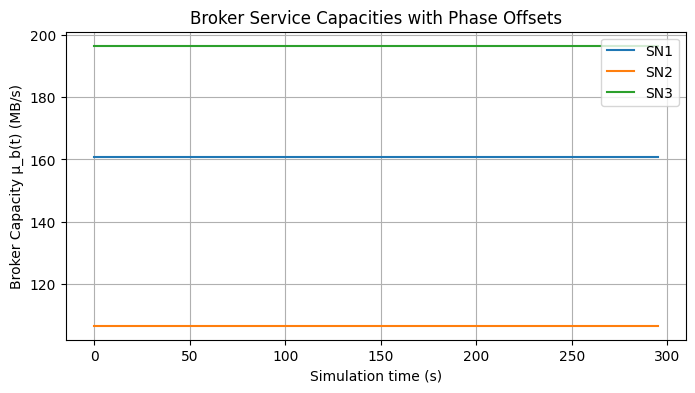

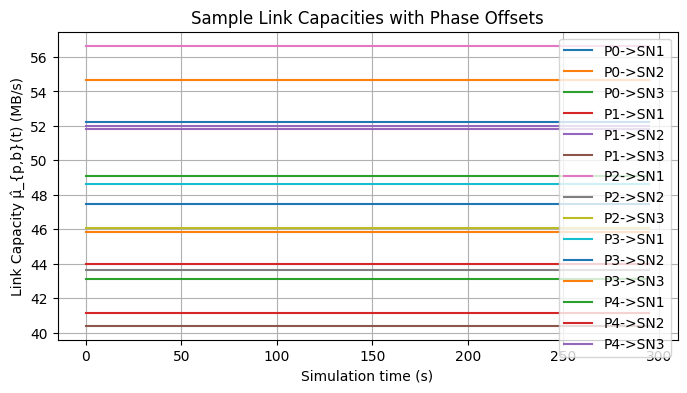


=== Sample of Time-Varying Link Capacities (MB/s) ===


,P0->SN1,P0->SN2,P0->SN3,P1->SN1,P1->SN2,P1->SN3,P2->SN1,P2->SN2,P2->SN3,P3->SN1,P3->SN2,P3->SN3,P4->SN1,P4->SN2,P4->SN3
0,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
5,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
10,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
15,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
20,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
25,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
30,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
35,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
40,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
45,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85



=== Sample of Time-Varying Broker Capacities (MB/s) ===


,SN1,SN2,SN3
0,160.75,106.51,196.56
5,160.75,106.51,196.56
10,160.75,106.51,196.56
15,160.75,106.51,196.56
20,160.75,106.51,196.56
25,160.75,106.51,196.56
30,160.75,106.51,196.56
35,160.75,106.51,196.56
40,160.75,106.51,196.56
45,160.75,106.51,196.56



Defined 11 dynamic environment combinations for upcoming runs.


In [11]:
# ============================================================
# Phase 2 (Updated): Heterogeneous Link and Broker Capacity Modeling + Optional Phase Offsets
# ============================================================

# Toggle for desynchronization between brokers and links
USE_PHASE_OFFSETS = True

# ------------------------------------------------------------
# Step 1: Baseline capacities (KB/s)
# ------------------------------------------------------------
link_base_cap = {}
link_phases = {}
for p in producers:
    for b in brokers:
        base = np.random.uniform(40, 60) * 1024  # KB/s
        link_base_cap[(p, b)] = base
        link_phases[(p, b)] = np.random.uniform(0, 2 * np.pi) if USE_PHASE_OFFSETS else 0.0

broker_base_cap = {}
broker_phases = {}
for b in brokers:
    broker_base_cap[b] = np.random.uniform(100, 200) * 1024  # KB/s
    broker_phases[b] = np.random.uniform(0, 2 * np.pi) if USE_PHASE_OFFSETS else 0.0

print("Baseline link capacities (μ̂ in KB/s):")
for (p, b), val in list(link_base_cap.items())[:15]:
    print(f"  {p}->{b}: {val/1024:.2f} MB/s")
print("...")

print("\nBaseline broker capacities (μ in MB/s):")
for b, val in broker_base_cap.items():
    print(f"  {b}: {val/1024:.2f} MB/s, phase={broker_phases[b]:.2f} rad")

# ------------------------------------------------------------
# Step 2: Capacity functions (with optional freezing)
# ------------------------------------------------------------
FREEZE_CAPS = True   # <<< Set True for constant baseline, False to restore sinusoidal variation

def vary_link_capacity(base_val, t, amp=LINK_AMP, period=LINK_PERIOD, noise_std=LINK_NOISE, phase=0):
    """Time-varying link capacity μ̂_{p,b}(t) with amplitude/period/noise."""
    if FREEZE_CAPS:
        return base_val
    fluct = 1 + amp * np.sin(2 * np.pi * t / period + phase)
    noise  = np.random.normal(0, noise_std)
    return base_val * max(0.2, fluct + noise)

def vary_broker_capacity(base_val, t, amp=BROKER_AMP, period=BROKER_PERIOD, noise_std=BROKER_NOISE, phase=0):
    """Time-varying broker capacity μ_b(t) with amplitude/period/noise."""
    if FREEZE_CAPS:
        return base_val
    fluct = 1 + amp * np.cos(2 * np.pi * t / period + phase)
    noise  = np.random.normal(0, noise_std)
    return base_val * max(0.3, fluct + noise)

# ------------------------------------------------------------
# Step 3: Demonstrate phase desynchronization
# ------------------------------------------------------------
time_points = np.arange(0, SIM_DURATION_SEC, TIME_WINDOW)

plt.figure(figsize=(8,4))
for b in brokers:
    trace = [vary_broker_capacity(broker_base_cap[b], t, phase=broker_phases[b]) for t in time_points]
    plt.plot(time_points, np.array(trace)/1024, label=f"{b}")
plt.xlabel("Simulation time (s)")
plt.ylabel("Broker Capacity μ_b(t) (MB/s)")
plt.title("Broker Service Capacities with Phase Offsets" if USE_PHASE_OFFSETS else "Broker Capacities (Synchronized)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
for (p,b) in list(link_base_cap.keys())[:min(15, len(link_base_cap))]:
    trace = [vary_link_capacity(link_base_cap[(p,b)], t, phase=link_phases[(p,b)]) for t in time_points]
    plt.plot(time_points, np.array(trace)/1024, label=f"{p}->{b}")
plt.xlabel("Simulation time (s)")
plt.ylabel("Link Capacity μ̂_{p,b}(t) (MB/s)")
plt.title("Sample Link Capacities with Phase Offsets" if USE_PHASE_OFFSETS else "Sample Link Capacities (Synchronized)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Step 4: Capacity Tables (Optional Diagnostic View)
# ------------------------------------------------------------
df_link_caps = pd.DataFrame({
    f"{p}->{b}": [vary_link_capacity(link_base_cap[(p,b)], t, phase=link_phases[(p,b)]) / 1024
                  for t in time_points]
    for (p,b) in link_base_cap
}, index=time_points)

df_broker_caps = pd.DataFrame({
    b: [vary_broker_capacity(broker_base_cap[b], t, phase=broker_phases[b]) / 1024
        for t in time_points]
    for b in brokers
}, index=time_points)

df_link_caps = df_link_caps.round(2)
df_broker_caps = df_broker_caps.round(2)

print("\n=== Sample of Time-Varying Link Capacities (MB/s) ===")
display(df_link_caps.head(10))
print("\n=== Sample of Time-Varying Broker Capacities (MB/s) ===")
display(df_broker_caps.head(10))

# ------------------------------------------------------------
# Step 5: Define Dynamic Condition Combos (Moderate + High Dynamics)
# ------------------------------------------------------------
combos = [
    # ------------------------
    # Moderate dynamics (1–6)
    # ------------------------
    (0.10, 120, 0.02, 0.10, 180, 0.03),  # Case 1: mild, slow
    (0.20,  80, 0.03, 0.25, 120, 0.04),  # Case 2: moderate
    (0.30,  60, 0.05, 0.30, 100, 0.05),  # Case 3: medium-fast
    (0.30,  40, 0.07, 0.30,  80, 0.07),  # Case 4: faster + moderate noise
    (0.40,  30, 0.10, 0.40,  60, 0.10),  # Case 5: high but still stable-ish
    (0.15,  90, 0.12, 0.20, 100, 0.08),  # Case 6: asymmetric noisy

    # ------------------------
    # High dynamics (7–10)
    # ------------------------
    (0.60,  30, 0.18, 0.60,  40, 0.18),  # Case 7: strong sinusoid + high noise
    (0.80,  30, 0.22, 0.80,  40, 0.22),  # Case 8: very strong + noisy, fast
    (0.70,  20, 0.25, 0.80,  30, 0.25),  # Case 9: ultra-fast, heavy noise (stress)
    (0.65,  25, 0.20, 0.70,  35, 0.20),  # Case 10: varied but still high dynamics
    (0.9,   15, 0.30, 0.9,   20, 0.30)   # Case 11: extreme oscillation (stress test)
]

print(f"\nDefined {len(combos)} dynamic environment combinations for upcoming runs.")


In [12]:
# ============================================================
# Build (lambdas_total_MB, MU_links_MB, MU_brokers_MB)
# using Phase-2 topology, all in MB/s
# ============================================================


producers_list = list(producers)
brokers_list   = list(brokers)

m = len(producers_list)
n = len(brokers_list)

print(f"Static instance: {m} producers × {n} brokers")


# ------------------------------------------------------------
# 1) Producer traffic in MB/s
# ------------------------------------------------------------
def producer_emission_MBps(p):
    """
    Total traffic emitted by producer p in MB/s.
    """
    total_kb = 0.0
    for t in producer_topic_pref[p]:
        unit, val = topic_avg_size[t]      # ("KB"/"MB", value)
        size_kb = val * 1024.0 if unit == "MB" else float(val)
        total_kb += topic_msg_rate[t] * size_kb   # KB/s

    return total_kb / 1024.0   # convert KB/s → MB/s


# Vector lambdas_total_MB = traffic per producer (MB/s)
lambdas_total_MB = np.array(
    [producer_emission_MBps(p) for p in producers_list],
    dtype=float
)


# ------------------------------------------------------------
# 2) MU_links_MB (link capacities P_i → B_j in MB/s)
# ------------------------------------------------------------
MU_links_MB = np.zeros((m, n), dtype=float)

for i, p in enumerate(producers_list):
    for j, b in enumerate(brokers_list):
        MU_links_MB[i, j] = float(link_base_cap[(p, b)]) / 1024.0   # KB/s → MB/s


# ------------------------------------------------------------
# 3) MU_brokers_MB (broker service rates in MB/s)
# ------------------------------------------------------------
MU_brokers_MB = np.array(
    [float(broker_base_cap[b]) / 1024.0 for b in brokers_list],
    dtype=float
)


# ------------------------------------------------------------
# Sanity printout (these MUST match the table in Phase-2)
# ------------------------------------------------------------

print("\n=== Producer emissions (MB/s) ===")
for p, lam in zip(producers_list, lambdas_total_MB):
    print(f"  {p}: {lam:.3f} MB/s")

print("\n=== MU_links (MB/s) ===")
print(pd.DataFrame(MU_links_MB, index=producers_list, columns=brokers_list).round(3))

print("\n=== MU_brokers (MB/s) ===")
for b, mu in zip(brokers_list, MU_brokers_MB):
    print(f"  {b}: {mu:.3f} MB/s")


Static instance: 5 producers × 3 brokers

=== Producer emissions (MB/s) ===
  P0: 0.156 MB/s
  P1: 0.098 MB/s
  P2: 30.059 MB/s
  P3: 30.010 MB/s
  P4: 0.107 MB/s

=== MU_links (MB/s) ===
       SN1     SN2     SN3
P0  47.491  54.640  43.120
P1  41.162  52.022  40.412
P2  56.649  43.636  46.085
P3  48.639  52.237  45.843
P4  49.121  43.993  51.848

=== MU_brokers (MB/s) ===
  SN1: 160.754 MB/s
  SN2: 106.505 MB/s
  SN3: 196.563 MB/s


In [13]:
# ============================================================
# Central + Distributed Solvers (FLOW-WEIGHTED ONLY)
# Matches the latest LaTeX writeup:
#   min  Σ_{i,j} λ_ij D_ij(λ_ij)  +  Σ_j Λ_j D_j(Λ_j)
# with M/M/1: D_ij(λ)=1/(μ_ij-λ),  D_j(Λ)=1/(μ_j-Λ)
# Distributed pricing uses:
#   p_j = D_j(Λ_j) + Λ_j D'_j(Λ_j) = μ_j / (μ_j - Λ_j)^2
# and source best-response solves:
#   min Σ_j [ λ_ij D_ij(λ_ij) + p_j λ_ij ]  s.t. Σ_j λ_ij=λ_i, λ_ij≥0
# ============================================================


lambdas_total = lambdas_total_MB.copy()      # shape (m,)
MU_links      = MU_links_MB.copy()           # shape (m,n)
MU_brokers    = MU_brokers_MB.copy()         # shape (n,)

m, n = MU_links.shape
eps = 1e-8


# ------------------------------------------------------------
# 0) Feasibility helpers (IMPORTANT)
# ------------------------------------------------------------
def check_global_feasibility(lambdas_total, MU_links, MU_brokers, eps=1e-8):
    if np.any(lambdas_total > (MU_links - 3*eps).sum(axis=1) + 1e-12):
        bad = np.where(lambdas_total > (MU_links - 3*eps).sum(axis=1) + 1e-12)[0]
        raise ValueError(f"Infeasible: some producer λ_i exceeds sum of its link caps. bad rows={bad.tolist()}")
    if lambdas_total.sum() > (MU_brokers - 3*eps).sum() + 1e-12:
        raise ValueError("Infeasible: total producer load exceeds total broker capacity.")


def waterfill_with_caps(total, caps, tol=1e-12, max_iter=2000):
    caps = np.maximum(np.asarray(caps, dtype=float), 0.0)
    if caps.sum() + 1e-12 < total:
        raise ValueError("waterfill_with_caps: infeasible total > sum caps")

    x = np.zeros_like(caps)
    active = caps > 0
    rem = total

    for _ in range(max_iter):
        if rem <= tol:
            break
        act_idx = np.where(active)[0]
        if len(act_idx) == 0:
            break

        cap_act = caps[act_idx] - x[act_idx]
        cap_act = np.maximum(cap_act, 0.0)
        s = cap_act.sum()
        if s <= tol:
            break

        add = rem * (cap_act / s)
        x_new = x[act_idx] + add

        overflow = x_new - caps[act_idx]
        if np.all(overflow <= tol):
            x[act_idx] = x_new
            rem = 0.0
            break

        hit = x_new >= caps[act_idx] - tol
        x[act_idx[hit]] = caps[act_idx[hit]]

        used = x.sum()
        rem = total - used
        active[act_idx[hit]] = False

    if abs(x.sum() - total) > 1e-8:
        slack = caps - x
        idx = np.argmax(slack)
        if slack[idx] > 0:
            x[idx] += (total - x.sum())
        x = np.minimum(x, caps)
        x = np.maximum(x, 0.0)

    return x


def initial_feasible_strict(lambdas_total, MU_links, MU_brokers, eps=1e-8):
    margin = 3 * eps
    rem_broker = (MU_brokers - margin).copy()
    L0 = np.zeros_like(MU_links)

    for i in range(m):
        caps_i = np.minimum(MU_links[i, :] - margin, rem_broker)
        caps_i = np.maximum(caps_i, 0.0)

        if caps_i.sum() + 1e-12 < lambdas_total[i]:
            raise ValueError(f"initial_feasible_strict infeasible at producer {i}: "
                             f"need {lambdas_total[i]}, have {caps_i.sum()}")

        alloc = waterfill_with_caps(lambdas_total[i], caps_i)
        L0[i, :] = alloc
        rem_broker -= alloc
        rem_broker = np.maximum(rem_broker, 0.0)

    return L0


check_global_feasibility(lambdas_total, MU_links, MU_brokers, eps=eps)
L0 = initial_feasible_strict(lambdas_total, MU_links, MU_brokers, eps=eps)


# ------------------------------------------------------------
# 1) FLOW-WEIGHTED objective (paper objective, M/M/1)
# ------------------------------------------------------------
def objective_flow_weighted(L_flat):
    L = L_flat.reshape(m, n)
    if np.any(L < -1e-12):
        return np.inf
    if np.any(L >= MU_links - eps):
        return np.inf
    s = L.sum(axis=0)
    if np.any(s >= MU_brokers - eps):
        return np.inf

    term_link   = 1.0 / (MU_links - L)
    term_broker = 1.0 / (MU_brokers - s)[None, :]
    return float((L * (term_link + term_broker)).sum())


def grad_flow_weighted(L_flat):
    L = L_flat.reshape(m, n)
    s = L.sum(axis=0)

    inv1   = 1.0 / (MU_links   - L)
    inv1_2 = inv1**2

    inv2   = 1.0 / (MU_brokers - s)
    inv2_2 = inv2**2

    # ∂F/∂λ_ij = μ_ij/(μ_ij-λ_ij)^2 + μ_j/(μ_j-Λ_j)^2
    grad = inv1 + L * inv1_2 + inv2[None, :] + s[None, :] * inv2_2[None, :]
    return grad.ravel()


# ------------------------------------------------------------
# NEW (Minimal): per-source mean end-to-end delay at a given L
# ------------------------------------------------------------
def per_source_mean_e2e(L, lambdas_total, MU_links, MU_brokers, eps=1e-12):
    """
    Returns:
      mean_i: shape (m,) per-source mean end-to-end delay
      e2e_ij: shape (m,n) per-(i,j) end-to-end delay
      access_ij: shape (m,n) access delay only
      broker_j: shape (n,) broker delay only
    """
    L = np.asarray(L, dtype=float)
    s = L.sum(axis=0)  # Λ_j

    access_ij = 1.0 / np.maximum(MU_links - L, eps)          # D_ij(λ_ij)
    broker_j  = 1.0 / np.maximum(MU_brokers - s, eps)        # D_j(Λ_j)
    e2e_ij    = access_ij + broker_j[None, :]

    num = (L * e2e_ij).sum(axis=1)
    den = np.maximum(lambdas_total, eps)
    mean_i = num / den

    return mean_i, e2e_ij, access_ij, broker_j


# ------------------------------------------------------------
# 2) Constraints: row sums == lambda_i, col sums <= mu_j, and bounds 0<=L_ij<=mu_ij
# ------------------------------------------------------------
lb = np.zeros((m, n)).ravel()
ub = (MU_links - eps).ravel()
bounds = Bounds(lb, ub)

A_eq = np.zeros((m, m * n))
for i in range(m):
    A_eq[i, i*n:(i+1)*n] = 1.0
b_eq = lambdas_total.copy()
lc_eq = LinearConstraint(A_eq, b_eq, b_eq)

A_ineq = np.zeros((n, m * n))
for j in range(n):
    A_ineq[j, j::n] = 1.0
lb_ineq = -np.inf * np.ones(n)
ub_ineq = MU_brokers - eps
lc_col = LinearConstraint(A_ineq, lb_ineq, ub_ineq)


# ------------------------------------------------------------
# 3) CENTRAL solver (flow-weighted)
# ------------------------------------------------------------
print("\n=== Central Solver: flow-weighted objective (paper objective) ===")
res_flow_central = minimize(
    objective_flow_weighted,
    L0.ravel(),
    jac=grad_flow_weighted,
    method="trust-constr",
    bounds=bounds,
    constraints=[lc_eq, lc_col],
    options={"maxiter": 1500, "verbose": 1}
)
L_flow_central = res_flow_central.x.reshape(m, n)
obj_flow_central = objective_flow_weighted(res_flow_central.x)
print("Success:", res_flow_central.success, "| Objective F* =", obj_flow_central)


# ------------------------------------------------------------
# 4) DISTRIBUTED solver (pricing-based, matches Section 4)
# ------------------------------------------------------------
def distributed_flow_weighted(
    lambdas_total,
    MU_links,
    MU_brokers,
    max_iter=500,
    eta=0.3,
    gamma=0.5,
    tol=1e-7,
    eps=1e-8
):
    m, n = MU_links.shape
    L = initial_feasible_strict(lambdas_total, MU_links, MU_brokers, eps=eps)
    p = np.zeros(n, dtype=float)

    history = {
        "objective": [],
        "rel_change": [],
        "max_broker_util": [],
        "broker_utils": [],        # per-broker util traces
        "source_mean_delay": [],   # <-- NEW (Minimal)
    }
    prev_norm = np.linalg.norm(L) + 1e-12

    def flow_objective(L):
        return objective_flow_weighted(L.ravel())

    def best_response_mm1(mu_row, p, lam_i):
        mu = np.asarray(mu_row, dtype=float)
        tiny = 1e-12

        lo = np.max(p + 1.0 / np.maximum(mu, tiny)) + 1e-12
        hi = lo + 1.0

        def total(alpha):
            denom = np.maximum(alpha - p, tiny)
            lam = np.maximum(0.0, mu - np.sqrt(mu / denom))
            lam = np.minimum(lam, mu - 3*eps)
            return lam.sum()

        while total(hi) < lam_i:
            hi *= 2.0
            if hi > 1e14:
                break

        for _ in range(80):
            mid = 0.5 * (lo + hi)
            if total(mid) >= lam_i:
                hi = mid
            else:
                lo = mid
        alpha_star = 0.5 * (lo + hi)

        denom = np.maximum(alpha_star - p, tiny)
        lam = np.maximum(0.0, mu - np.sqrt(mu / denom))
        lam = np.minimum(lam, mu - 3*eps)

        s = lam.sum()
        caps = np.maximum(mu - 3*eps, 0.0)
        if s <= 1e-15:
            lam = waterfill_with_caps(lam_i, caps)
        else:
            lam *= lam_i / s
            if np.any(lam > caps + 1e-9):
                lam = waterfill_with_caps(lam_i, caps)
        return lam

    for it in range(max_iter):
        # ---- Price update: p_j = μ_j / (μ_j - Λ_j)^2
        s = L.sum(axis=0)
        p_inst = MU_brokers / np.maximum(MU_brokers - s, 3*eps)**2
        p = (1 - gamma) * p + gamma * p_inst

        # ---- Source best responses
        L_br = np.zeros_like(L)
        for i in range(m):
            L_br[i, :] = best_response_mm1(MU_links[i, :], p, lambdas_total[i])

        # ---- Damped update with broker-feasibility backoff
        direction = L_br - L
        ds = direction.sum(axis=0)
        s = L.sum(axis=0)

        t = 1.0
        for j in range(n):
            if ds[j] > 0:
                t = min(t, float((MU_brokers[j] - 5*eps - s[j]) / ds[j]))
        t = max(0.0, min(1.0, t))
        step = eta * t

        L_new = L + step * direction
        L_new = np.minimum(L_new, MU_links - 5*eps)
        L_new = np.maximum(L_new, 0.0)

        # ---- tiny numerical drift correction: fix row sums by nudging the most-slack entry
        for i in range(m):
            err = lambdas_total[i] - L_new[i, :].sum()
            if abs(err) > 1e-8:
                slack = (MU_links[i, :] - 5*eps) - L_new[i, :]
                jstar = int(np.argmax(slack))
                if slack[jstar] > 1e-12:
                    L_new[i, jstar] += err
                    # clamp again
                    L_new[i, :] = np.minimum(L_new[i, :], MU_links[i, :] - 5*eps)
                    L_new[i, :] = np.maximum(L_new[i, :], 0.0)

        # ---- broker feasibility check; if violated, back off once more
        s_new = L_new.sum(axis=0)
        if np.any(s_new >= MU_brokers - 3*eps):
            step *= 0.5
            L_new = L + step * direction
            L_new = np.minimum(L_new, MU_links - 5*eps)
            L_new = np.maximum(L_new, 0.0)

        diff = np.linalg.norm(L_new - L) / prev_norm
        L = L_new
        prev_norm = np.linalg.norm(L) + 1e-12

        history["objective"].append(flow_objective(L))
        history["rel_change"].append(float(diff))

        # ---- NEW (Minimal): store per-source mean delay each iteration
        mean_i, _, _, _ = per_source_mean_e2e(L, lambdas_total, MU_links, MU_brokers)
        history["source_mean_delay"].append(mean_i.copy())

        util_vec = (L.sum(axis=0) / MU_brokers).copy()
        history["broker_utils"].append(util_vec)
        history["max_broker_util"].append(float(util_vec.max()))

        if diff < tol:
            break

    return {
        "L": L,
        "objective": flow_objective(L),
        "iterations": it + 1,
        "history": history,
        "prices": p,
    }


# ------------------------------------------------------------
# 5) Run distributed solver (flow-weighted only)
# ------------------------------------------------------------
print("\n=== Distributed Solver: flow-weighted (pricing-based) ===")
dist_flow = distributed_flow_weighted(
    lambdas_total, MU_links, MU_brokers,
    max_iter=400, eta=0.3, gamma=0.5, tol=1e-7, eps=eps
)
print("Iterations:", dist_flow["iterations"], "| Objective F_dist =", dist_flow["objective"])


# ------------------------------------------------------------
# 6) Compare broker loads for CENTRAL vs DISTRIBUTED
# ------------------------------------------------------------
def broker_loads(L):
    return L.sum(axis=0)

solutions = {
    "central_flow": L_flow_central,
    "dist_flow":    dist_flow["L"],
}

print("\n=== Broker utilizations per solution (Lambda_j / mu_j) ===")
for name, L_sol in solutions.items():
    loads = broker_loads(L_sol)
    util  = loads / MU_brokers
    print(f"{name}:")
    for b_name, u in zip(brokers_list, util):
        print(f"  {b_name}: {u:.3f}")
    print()

print("Objective gap (dist - central):", float(dist_flow["objective"] - obj_flow_central))






=== Central Solver: flow-weighted objective (paper objective) ===
`gtol` termination condition is satisfied.
Number of iterations: 33, function evaluations: 23, CG iterations: 69, optimality: 3.28e-09, constraint violation: 3.55e-15, execution time: 0.076 s.
Success: True | Objective F* = 2.0157474290466064

=== Distributed Solver: flow-weighted (pricing-based) ===
Iterations: 38 | Objective F_dist = 2.0159479318365103

=== Broker utilizations per solution (Lambda_j / mu_j) ===
central_flow:
  SN1: 0.158
  SN2: 0.139
  SN3: 0.103

dist_flow:
  SN1: 0.159
  SN2: 0.139
  SN3: 0.102

Objective gap (dist - central): 0.00020050278990391135


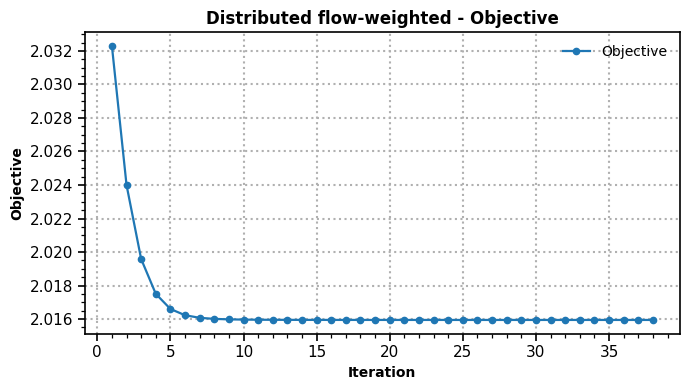

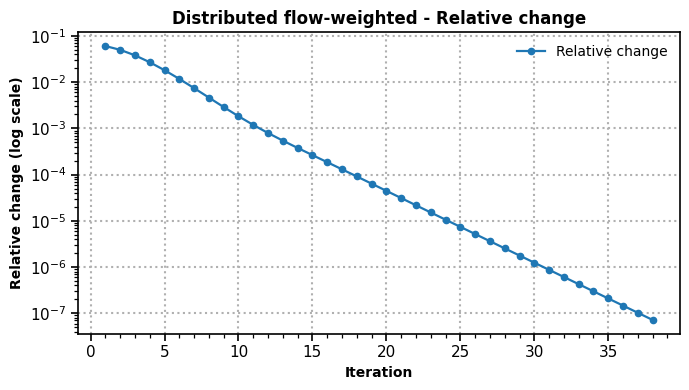

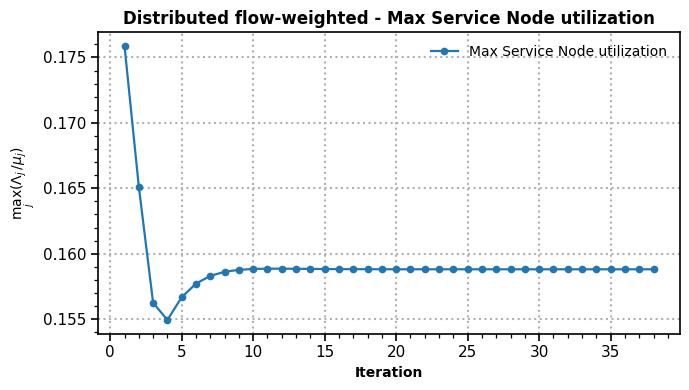

In [14]:
# ------------------------------------------------------------
# 10) Convergence plots for distributed solver (paper-like)
# ------------------------------------------------------------
# Colab-safe: ensure plots render
# (optional) %matplotlib inline


def _stylize_axes(ax, xlabel, ylabel, title):
    ax.set_xlabel(xlabel, fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_title(title, fontweight="bold")

    # dotted grid similar to your screenshot
    ax.grid(True, which="major", linestyle=":", linewidth=1.5)
    ax.minorticks_on()

    # slightly thicker spines/ticks for a paper look
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    ax.tick_params(axis="both", which="major", width=1.2, length=5, labelsize=11)
    ax.tick_params(axis="both", which="minor", width=0.9, length=3)

def plot_history(history, title, filename=None, marker="o", markersize=4.5):
    iters = np.arange(1, len(history["objective"]) + 1)

    # Guard: nothing to plot
    if len(iters) == 0:
        print(f"[plot_history] Empty history for: {title}")
        return

    # ---------- Objective ----------
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        iters, history["objective"],
        linestyle="-", linewidth=1.6,
        marker=marker, markersize=markersize,
        label="Objective"
    )
    _stylize_axes(ax, "Iteration", "Objective", f"{title} - Objective")
    ax.legend(frameon=False)
    fig.tight_layout()
    if filename:
        fig.savefig(filename + "_obj.png", dpi=300, bbox_inches="tight")
        fig.savefig(filename + "_obj.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # ---------- Relative change (log) ----------
    rel = np.asarray(history["rel_change"], dtype=float)
    rel = np.maximum(rel, 1e-16)  # avoid log(0) which can blank plots

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        iters, rel,
        linestyle="-", linewidth=1.6,
        marker=marker, markersize=markersize,
        label="Relative change"
    )
    ax.set_yscale("log")
    _stylize_axes(ax, "Iteration", "Relative change (log scale)", f"{title} - Relative change")
    ax.legend(frameon=False)
    fig.tight_layout()
    if filename:
        fig.savefig(filename + "_relchange.png", dpi=300, bbox_inches="tight")
        fig.savefig(filename + "_relchange.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # ---------- Max broker utilization ----------
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        iters, history["max_broker_util"],
        linestyle="-", linewidth=1.6,
        marker=marker, markersize=markersize,
        label="Max Service Node utilization"
    )
    _stylize_axes(ax, "Iteration", r"$\max_j(\Lambda_j/\mu_j)$", f"{title} - Max Service Node utilization")
    ax.legend(frameon=False)
    fig.tight_layout()
    if filename:
        fig.savefig(filename + "_util.png", dpi=300, bbox_inches="tight")
        fig.savefig(filename + "_util.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

# Only flow-weighted remains
plot_history(dist_flow["history"], "Distributed flow-weighted", marker="o")


,Central,Distributed (final)
SN1,0.1581,0.1588
SN2,0.1386,0.1390
SN3,0.1030,0.1022


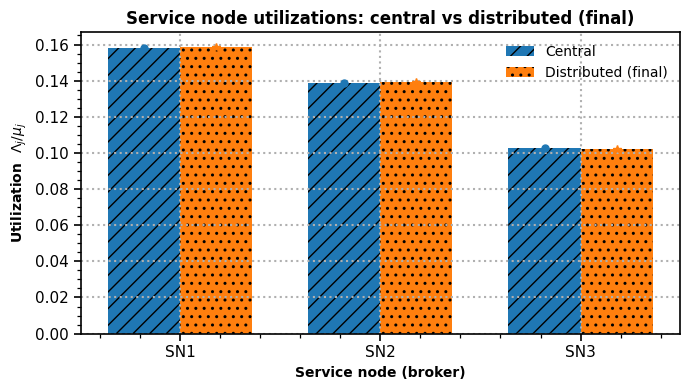

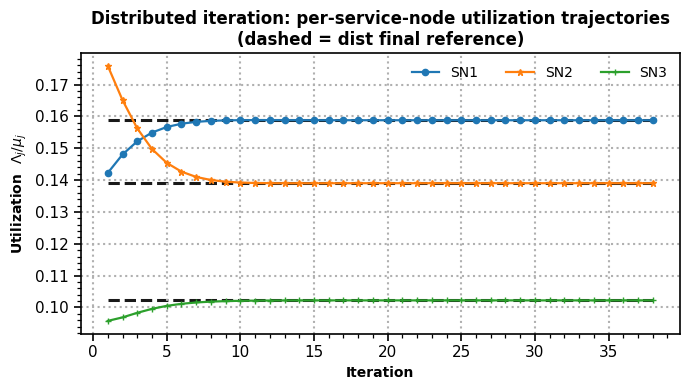

In [15]:
# ============================================================
# (NEW) Service node (broker) utilization plots for comparison
# Uses existing: L_flow_central, dist_flow["L"], MU_brokers, brokers_list, _stylize_axes
# ============================================================


# ---- (A) numbers (optional small table, consistent with what you already had)
util_central = L_flow_central.sum(axis=0) / MU_brokers
util_dist    = dist_flow["L"].sum(axis=0) / MU_brokers

df_util_compare = pd.DataFrame(
    {"Central": util_central, "Distributed (final)": util_dist},
    index=brokers_list
).round(4)

display(df_util_compare)

# ---- (B) bar chart: central vs distributed (final)
x = np.arange(len(brokers_list))
w = 0.36

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, util_central, width=w, label="Central", hatch="//")
ax.bar(x + w/2, util_dist,    width=w, label="Distributed (final)", hatch="..")

# optional: put markers on top of bars (keeps your “shape” consistency)
ax.plot(x - w/2, util_central, linestyle="None", marker="o", markersize=5)
ax.plot(x + w/2, util_dist,    linestyle="None", marker="*", markersize=6)

ax.set_xticks(x)
ax.set_xticklabels(brokers_list)

_stylize_axes(ax, "Service node (broker)", r"Utilization  $\Lambda_j/\mu_j$",
              "Service node utilizations: central vs distributed (final)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
plt.close(fig)

# ---- (C) trajectories over distributed iterations (per-service-node utilization)
U = np.asarray(dist_flow["history"]["broker_utils"], dtype=float)  # (T, n)
iters = np.arange(1, U.shape[0] + 1)

# reference (deterministic distributed final utilization per broker)
util_ref = dist_flow["L"].sum(axis=0) / MU_brokers   # shape (n,)

fig, ax = plt.subplots(figsize=(7, 4))
markers = ["o", "*", "+", "x", "D"]

for j, b in enumerate(brokers_list):
    ax.plot(
        iters, U[:, j],
        linestyle="-", linewidth=1.6,
        marker=markers[j % len(markers)], markersize=4.5,
        label=f"{b}"
    )
    # dashed reference line for this broker
    ax.hlines(
        util_ref[j],
        iters[0], iters[-1],
        linestyles="--",
        linewidth=2.2,
        color="k",
        alpha=0.9,
        zorder=0
    )

_stylize_axes(
    ax, "Iteration", r"Utilization  $\Lambda_j/\mu_j$",
    "Distributed iteration: per-service-node utilization trajectories\n(dashed = dist final reference)"
)
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
plt.show()
plt.close(fig)



,central_mean_delay,dist_mean_delay,abs_gap,rel_gap
P0,0.028946,0.028700,0.000246,0.008504
P1,0.030477,0.030295,0.000182,0.005976
P2,0.032973,0.032975,0.000002,0.000074
P3,0.033804,0.033806,0.000002,0.000068
P4,0.024999,0.026067,0.001068,0.042727


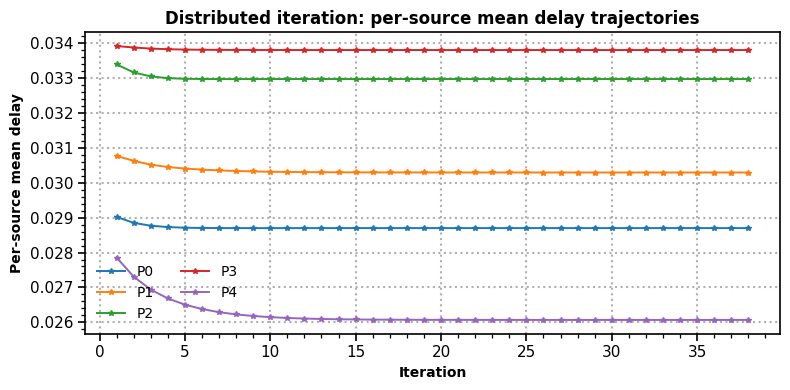

In [16]:
# ============================================================
# Plotting per-source mean delays:
#   (A) table (central vs dist final)
#   (B) bar chart
#   (C) trajectories over iterations (dist), with central reference
# ============================================================


def per_source_mean_delay(L, lambdas_total, MU_links, MU_brokers, eps=1e-12):
    """
    Returns:
      mean_i: shape (m,)  mean delay for each source i, weighted by its own flow split
      e2e_ij: shape (m,n) per-path delay D_ij(λ_ij)+D_j(Λ_j)
      access_ij: shape (m,n) access delay D_ij(λ_ij)
      broker_j: shape (n,)  broker delay D_j(Λ_j)
    """
    L = np.asarray(L, dtype=float)
    m, n = L.shape
    s = L.sum(axis=0)

    access_ij = 1.0 / np.maximum(MU_links - L, eps)                  # D_ij(λ_ij)
    broker_j  = 1.0 / np.maximum(MU_brokers - s, eps)                # D_j(Λ_j)
    delay_ij    = access_ij + broker_j[None, :]                        # D_ij + D_j

    mean_i = np.zeros(m, dtype=float)
    for i in range(m):
        denom = max(lambdas_total[i], eps)
        mean_i[i] = float((L[i, :] * delay_ij[i, :]).sum() / denom)

    return mean_i, delay_ij, access_ij, broker_j


# ---- (A) table: central vs dist final
mean_central, _, _, _ = per_source_mean_e2e(L_flow_central, lambdas_total, MU_links, MU_brokers)
mean_dist,    _, _, _ = per_source_mean_e2e(dist_flow["L"],  lambdas_total, MU_links, MU_brokers)

df_src = pd.DataFrame({
    "central_mean_delay": mean_central,
    "dist_mean_delay": mean_dist,
    "abs_gap": np.abs(mean_dist - mean_central),
    "rel_gap": np.abs(mean_dist - mean_central) / np.maximum(mean_central, 1e-12),
}, index=producers_list)

display(df_src.round(6))

"""
# ---- (B) bar chart: per-source mean delay (central vs dist final)
x = np.arange(len(producers_list))
w = 0.38

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - w/2, mean_central, width=w, label="Central")
ax.bar(x + w/2, mean_dist,    width=w, label="Distributed (final)")

ax.set_xticks(x)
ax.set_xticklabels(producers_list)
ax.set_xlabel("Source (producer)")
ax.set_ylabel("Mean delay (flow-weighted)")
ax.set_title("Per-source mean delay: central vs distributed (final)")
ax.grid(True, which="major", linestyle=":", linewidth=1.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
plt.close(fig)
"""

# ---- (C) trajectories: per-source mean delay over distributed iterations
S = np.asarray(dist_flow["history"]["source_mean_delay"], dtype=float)   # shape (T, m)
iters = np.arange(1, S.shape[0] + 1)

fig, ax = plt.subplots(figsize=(8,4))
for i, p in enumerate(producers_list):
    ax.plot(
        iters, S[:, i],
        marker="*", markersize=3.8,
        linewidth=1.4,
        label=f"{p}"
    )

# styling: match other diags
try:
    _stylize_axes(
        ax,
        "Iteration",
        "Per-source mean delay",
        "Distributed iteration: per-source mean delay trajectories"
    )
except NameError:
    ax.set_xlabel("Iteration", fontweight="bold")
    ax.set_ylabel("Per-source mean delay", fontweight="bold")
    ax.set_title("Distributed iteration: per-source mean delay trajectories", fontweight="bold")
    ax.grid(True, which="major", linestyle=":", linewidth=1.2)

ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()
plt.close(fig)




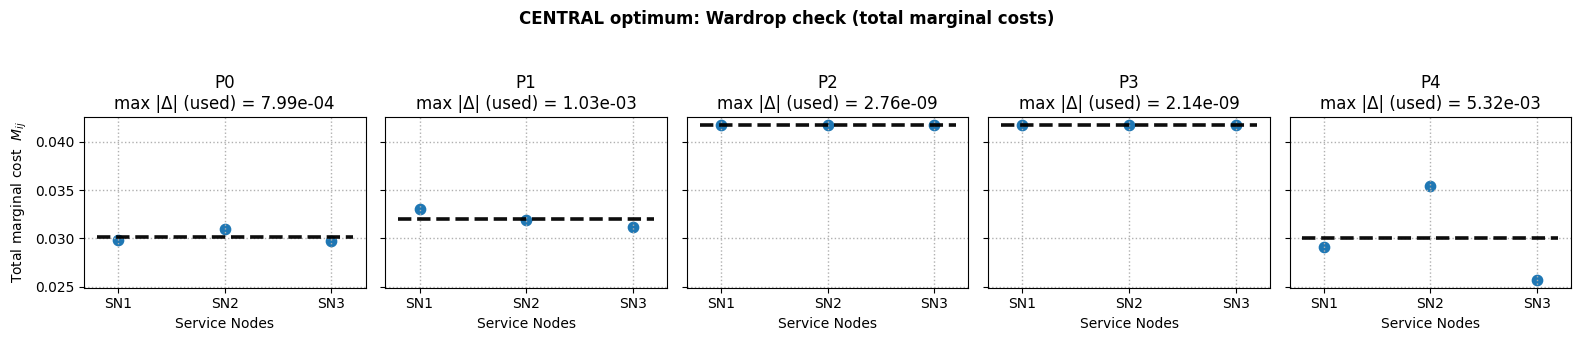

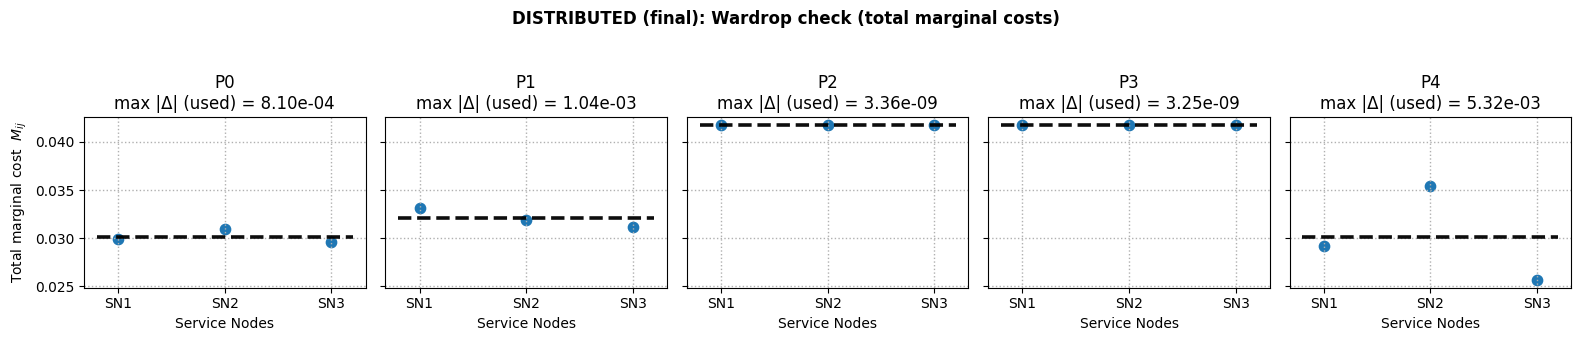

In [17]:
def wardrop_marginals_mm1(L, MU_links, MU_brokers, eps=1e-8):
    """
    Returns:
      M_total: (m,n) total marginal costs M_ij
      C_access: (m,n) access marginal costs
      C_server: (n,)  server marginal costs (prices)
      Lambda:  (n,)   broker loads
    """
    L = np.asarray(L, dtype=float)
    MU_links = np.asarray(MU_links, dtype=float)
    MU_brokers = np.asarray(MU_brokers, dtype=float)

    Lambda = L.sum(axis=0)  # (n,)

    # Access marginal: mu_ij / (mu_ij - lambda_ij)^2
    denom_link = np.maximum(MU_links - L, 3*eps)
    C_access = MU_links / (denom_link**2)

    # Server marginal: mu_j / (mu_j - Lambda_j)^2
    denom_srv = np.maximum(MU_brokers - Lambda, 3*eps)
    C_server = MU_brokers / (denom_srv**2)

    M_total = C_access + C_server[None, :]
    return M_total, C_access, C_server, Lambda


def plot_wardrop_per_source(M_total, L, producers_list, brokers_list,
                            title="Wardrop check: total marginal costs per source",
                            used_thresh=1e-10):
    """
    For each source i, plot M_ij across brokers j.
    Used routes (lambda_ij > used_thresh) are emphasized.
    Dashed black line = mean marginal cost over USED routes for that source.
    """
    L = np.asarray(L, dtype=float)
    M_total = np.asarray(M_total, dtype=float)

    m, n = M_total.shape
    x = np.arange(n)

    fig, axes = plt.subplots(1, m, figsize=(3.2*m, 3.2), sharey=True)
    if m == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        used = L[i, :] > used_thresh

        # plot all brokers
        ax.scatter(x[~used], M_total[i, ~used], marker="o", facecolors="none",
                   edgecolors="tab:gray", linewidths=1.2, s=45, label="unused")
        ax.scatter(x[used],  M_total[i, used],  marker="o",
                   s=55, label="used")

        # Wardrop reference: mean over used paths
        if np.any(used):
            ref = float(M_total[i, used].mean())
            ax.hlines(ref, x[0]-0.2, x[-1]+0.2, linestyles="--",
                      color="k", linewidth=2.6, alpha=0.95)

            # show max deviation among used
            dev = np.max(np.abs(M_total[i, used] - ref))
            ax.set_title(f"{producers_list[i]}\nmax |Δ| (used) = {dev:.2e}")
        else:
            ax.set_title(f"{producers_list[i]}\n(no used routes?)")

        ax.set_xticks(x)
        ax.set_xticklabels(brokers_list, rotation=0)
        ax.grid(True, linestyle=":", linewidth=1.0)
        ax.set_xlabel("Service Nodes")

    axes[0].set_ylabel("Total marginal cost  $M_{ij}$")
    fig.suptitle(title, y=1.05, fontweight="bold")
    fig.tight_layout()
    plt.show()
    plt.close(fig)


# --- CENTRAL Wardrop check ---
M_c, _, p_c, Lambda_c = wardrop_marginals_mm1(L_flow_central, MU_links, MU_brokers, eps=eps)
plot_wardrop_per_source(
    M_c, L_flow_central,
    producers_list, brokers_list,
    title="CENTRAL optimum: Wardrop check (total marginal costs)"
)

# --- DISTRIBUTED (final iterate) Wardrop check ---
L_dist = dist_flow["L"]
M_d, _, p_d, Lambda_d = wardrop_marginals_mm1(L_dist, MU_links, MU_brokers, eps=eps)
plot_wardrop_per_source(
    M_d, L_dist,
    producers_list, brokers_list,
    title="DISTRIBUTED (final): Wardrop check (total marginal costs)"
)


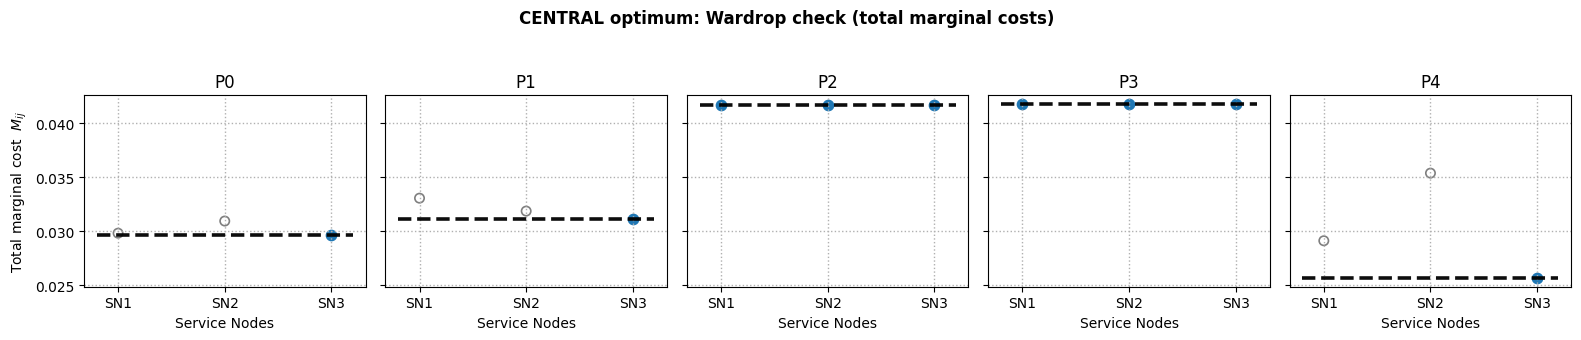

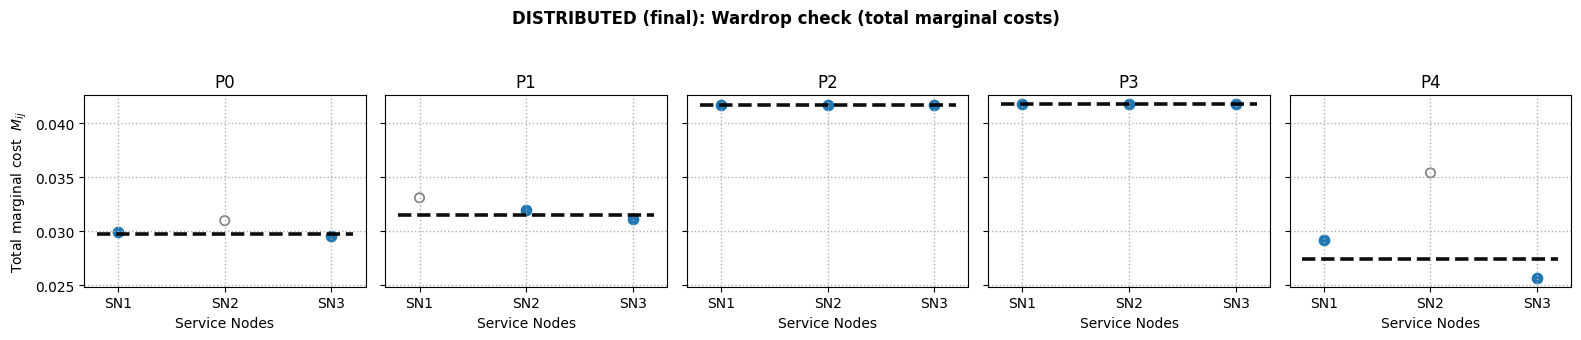

In [18]:
def plot_wardrop_per_source(M_total, L, lambdas_total, producers_list, brokers_list,
                            title="Wardrop check: total marginal costs per source",
                            used_rel=1e-3, used_abs=1e-6):
    """
    used if lambda_ij >= max(used_abs, used_rel * lambda_i)
    Dashed black line = mean marginal cost over USED routes for that source.
    (Option A) No per-panel "max |Δ| (used)" annotation in titles.
    """
    L = np.asarray(L, dtype=float)
    M_total = np.asarray(M_total, dtype=float)
    lambdas_total = np.asarray(lambdas_total, dtype=float)

    m, n = M_total.shape
    x = np.arange(n)

    fig, axes = plt.subplots(1, m, figsize=(3.2*m, 3.2), sharey=True)
    if m == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        thresh_i = max(float(used_abs), float(used_rel) * float(lambdas_total[i]))
        used = L[i, :] >= thresh_i

        # plot unused vs used
        ax.scatter(
            x[~used], M_total[i, ~used],
            marker="o", facecolors="none",
            edgecolors="tab:gray", linewidths=1.2, s=45
        )
        ax.scatter(
            x[used], M_total[i, used],
            marker="o", s=55
        )

        # Wardrop reference: mean over used paths
        if np.any(used):
            ref = float(M_total[i, used].mean())
            ax.hlines(
                ref, x[0]-0.2, x[-1]+0.2,
                linestyles="--", color="k",
                linewidth=2.6, alpha=0.95
            )
            ax.set_title(f"{producers_list[i]}")
        else:
            ax.set_title(f"{producers_list[i]}")

        ax.set_xticks(x)
        ax.set_xticklabels(brokers_list)
        ax.grid(True, linestyle=":", linewidth=1.0)
        ax.set_xlabel("Service Nodes")

    axes[0].set_ylabel(r"Total marginal cost  $M_{ij}$")
    fig.suptitle(title, y=1.05, fontweight="bold")
    fig.tight_layout()
    plt.show()
    plt.close(fig)


# CENTRAL
M_c, _, _, _ = wardrop_marginals_mm1(L_flow_central, MU_links, MU_brokers, eps=eps)
plot_wardrop_per_source(
    M_c, L_flow_central, lambdas_total, producers_list, brokers_list,
    title="CENTRAL optimum: Wardrop check (total marginal costs)"
)

# DISTRIBUTED (final)
L_dist = dist_flow["L"]
M_d, _, _, _ = wardrop_marginals_mm1(L_dist, MU_links, MU_brokers, eps=eps)
plot_wardrop_per_source(
    M_d, L_dist, lambdas_total, producers_list, brokers_list,
    title="DISTRIBUTED (final): Wardrop check (total marginal costs)"
)


In [19]:
# ============================================================
# Stochastic M/M/1 simulation of the DISTRIBUTED pricing scheme
# - Poisson arrivals per producer
# - Random (or RR) splitting according to x_ij(t)
# - Per-(i,j) access queue + per-broker server queue
# - Broker EWMA estimates arrival rate -> price p_j(t)
# - Producers recompute best-response split each window (synchronous)
# ============================================================

# ------------------------
# Keep these SAME as before
# ------------------------
SIM_DURATION_SEC = 300
TIME_WINDOW      = 5
WARMUP_WINDOWS   = 4

# ------------------------
# New stochastic knobs (report these)
# ------------------------
PACKET_MB   = 1.0     # 1 packet = 1 MB of traffic
BETA_LAMBDA = 0.30    # EWMA smoothing for broker arrival-rate estimate
GAMMA_PRICE = 0.50    # optional smoothing on prices p_j
ETA_SPLIT   = 0.35    # inertia on split update (like damping for x_ij)

ROUTING_MODE = "random"   # "random" (recommended) or "round_robin"

np.random.seed(42)

# ------------------------
# Convert rates from MB/s -> packets/s
# ------------------------
lambdas_pkt     = np.asarray(lambdas_total_MB, dtype=float) / PACKET_MB     # (m,)
MU_links_pkt    = np.asarray(MU_links_MB, dtype=float) / PACKET_MB          # (m,n)
MU_brokers_pkt  = np.asarray(MU_brokers_MB, dtype=float) / PACKET_MB        # (n,)

m, n = MU_links_pkt.shape
dt = float(TIME_WINDOW)
T  = int(SIM_DURATION_SEC // TIME_WINDOW)

eps = 1e-9

# ------------------------
# Initialize split x_ij from your feasible L0 (if you already have it).
# If L0 doesn't exist in your notebook state, fall back to proportional-to-cap.
# ------------------------
try:
    # L0 in MB/s -> convert to packets/s
    L0_pkt = (L0 / PACKET_MB).copy()
    x = L0_pkt / np.maximum(lambdas_pkt[:, None], eps)
except NameError:
    # fallback: x_ij ∝ MU_links_ij
    x = MU_links_pkt / np.maximum(MU_links_pkt.sum(axis=1, keepdims=True), eps)

# ensure rows sum to 1
x = np.maximum(x, 0.0)
x = x / np.maximum(x.sum(axis=1, keepdims=True), eps)

# ------------------------
# Best-response solver (same math as your distributed solver)
# returns λ_ij in packets/s given μ_ij, p_j, and λ_i
# ------------------------
def best_response_mm1(mu_row, p, lam_i, eps=1e-10):
    mu = np.asarray(mu_row, dtype=float)
    p  = np.asarray(p, dtype=float)

    tiny = 1e-12
    lo = np.max(p + 1.0 / np.maximum(mu, tiny)) + 1e-12
    hi = lo + 1.0

    def total(alpha):
        denom = np.maximum(alpha - p, tiny)
        lam = np.maximum(0.0, mu - np.sqrt(mu / denom))
        lam = np.minimum(lam, mu - 3*eps)
        return lam.sum()

    while total(hi) < lam_i:
        hi *= 2.0
        if hi > 1e14:
            break

    for _ in range(80):
        mid = 0.5 * (lo + hi)
        if total(mid) >= lam_i:
            hi = mid
        else:
            lo = mid
    alpha_star = 0.5 * (lo + hi)

    denom = np.maximum(alpha_star - p, tiny)
    lam = np.maximum(0.0, mu - np.sqrt(mu / denom))
    lam = np.minimum(lam, mu - 3*eps)

    s = lam.sum()
    caps = np.maximum(mu - 3*eps, 0.0)
    if s <= 1e-15:
        # degenerate: allocate proportional to caps
        if caps.sum() < lam_i - 1e-9:
            raise ValueError("Infeasible best response: demand exceeds caps.")
        lam = lam_i * caps / np.maximum(caps.sum(), eps)
    else:
        lam *= lam_i / s
        lam = np.minimum(lam, caps)

        # renormalize if clipped
        if abs(lam.sum() - lam_i) > 1e-6:
            slack = caps - lam
            if slack.sum() > 0:
                lam += (lam_i - lam.sum()) * slack / slack.sum()
            lam = np.minimum(lam, caps)

    return lam

# ------------------------
# Routing allocation within each window
# ------------------------
rr_ptr = np.zeros(m, dtype=int)

def allocate_counts(A_i, probs, mode="random", i=None):
    probs = np.asarray(probs, dtype=float)
    probs = np.maximum(probs, 0.0)
    probs = probs / np.maximum(probs.sum(), eps)

    if A_i <= 0:
        return np.zeros_like(probs, dtype=int)

    if mode == "random":
        return np.random.multinomial(A_i, probs)

    # round-robin approx for target proportions
    counts = np.floor(A_i * probs).astype(int)
    rem = int(A_i - counts.sum())
    if rem > 0:
        start = rr_ptr[i] if i is not None else 0
        order = (start + np.arange(len(probs))) % len(probs)
        for k in range(rem):
            counts[order[k % len(probs)]] += 1
        if i is not None:
            rr_ptr[i] = (start + rem) % len(probs)
    return counts

# ------------------------
# State: queues
# ------------------------
q_link   = np.zeros((m, n), dtype=int)   # per-(i,j) access queue length (packets)
q_broker = np.zeros(n, dtype=int)        # per-broker queue length (packets)

# EWMA arrival-rate estimate at brokers (packets/s)
Lambda_hat = np.zeros(n, dtype=float)

# prices
p = np.zeros(n, dtype=float)

# ------------------------
# History for plots + comparisons
# ------------------------
hist_time       = np.arange(T) * dt
hist_p          = np.zeros((T, n), dtype=float)
hist_util       = np.zeros((T, n), dtype=float)   # <-- USED BY YOUR COMPARISON CELL
hist_q_broker   = np.zeros((T, n), dtype=float)
hist_mean_delay = np.zeros((T, m), dtype=float)
hist_x          = np.zeros((T, m, n), dtype=float)

def delay_from_queue(q, mu):
    # rough instantaneous sojourn estimate: (q/mu) + (1/mu)
    mu = np.maximum(mu, 1e-12)
    return (q / mu) + (1.0 / mu)

# ------------------------
# Main synchronous loop
# ------------------------
for t_idx in range(T):
    # 1) Producer arrivals (packets in this window)
    A_i = np.random.poisson(lambdas_pkt * dt)   # (m,)

    # split into paths
    A_ij = np.zeros((m, n), dtype=int)
    for i in range(m):
        A_ij[i, :] = allocate_counts(int(A_i[i]), x[i, :], mode=ROUTING_MODE, i=i)

    # 2) Access/link queues: add arrivals, serve
    dep_link = np.zeros((m, n), dtype=int)
    for i in range(m):
        for j in range(n):
            q_link[i, j] += A_ij[i, j]
            svc = np.random.poisson(MU_links_pkt[i, j] * dt)
            served = min(q_link[i, j], int(svc))
            q_link[i, j] -= served
            dep_link[i, j] = served

    # 3) Broker queues: arrivals = sum departures from links, serve
    arrivals_broker = dep_link.sum(axis=0).astype(int)  # (n,)
    dep_broker = np.zeros(n, dtype=int)
    for j in range(n):
        q_broker[j] += arrivals_broker[j]
        svc = np.random.poisson(MU_brokers_pkt[j] * dt)
        served = min(q_broker[j], int(svc))
        q_broker[j] -= served
        dep_broker[j] = served

    # 4) Broker EWMA arrival-rate estimate -> price update
    inst_rate = arrivals_broker / dt  # packets/s
    Lambda_hat = (1.0 - BETA_LAMBDA) * Lambda_hat + BETA_LAMBDA * inst_rate

    p_inst = MU_brokers_pkt / np.maximum(MU_brokers_pkt - Lambda_hat, 1e-6)**2
    p = (1.0 - GAMMA_PRICE) * p + GAMMA_PRICE * p_inst

    # 5) Producer split update after warmup (best-response + inertia)
    if t_idx >= WARMUP_WINDOWS:
        x_target = np.zeros((m, n), dtype=float)
        for i in range(m):
            lam_br = best_response_mm1(MU_links_pkt[i, :], p, lambdas_pkt[i])
            x_target[i, :] = lam_br / np.maximum(lambdas_pkt[i], eps)

        x = (1.0 - ETA_SPLIT) * x + ETA_SPLIT * x_target
        x = np.maximum(x, 0.0)
        x = x / np.maximum(x.sum(axis=1, keepdims=True), eps)

    # 6) Record delay/util/splits
    util = Lambda_hat / np.maximum(MU_brokers_pkt, 1e-12)

    d_link = delay_from_queue(q_link.astype(float), MU_links_pkt)      # (m,n)
    d_srv  = delay_from_queue(q_broker.astype(float), MU_brokers_pkt)  # (n,)
    d_e2e  = d_link + d_srv[None, :]                                   # (m,n)
    mean_delay_i = (x * d_e2e).sum(axis=1)                             # (m,)

    hist_p[t_idx, :]          = p
    hist_util[t_idx, :]       = util
    hist_q_broker[t_idx, :]   = q_broker
    hist_mean_delay[t_idx, :] = mean_delay_i
    hist_x[t_idx, :, :]       = x

print("Done. Stochastic simulation finished.")
print("Routing mode:", ROUTING_MODE, "| PACKET_MB:", PACKET_MB)
print("T windows:", T, "| window:", dt, "sec | warmup windows:", WARMUP_WINDOWS)


Done. Stochastic simulation finished.
Routing mode: random | PACKET_MB: 1.0
T windows: 60 | window: 5.0 sec | warmup windows: 4


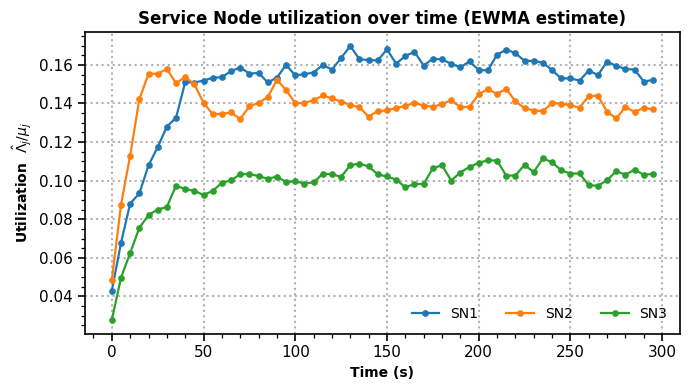

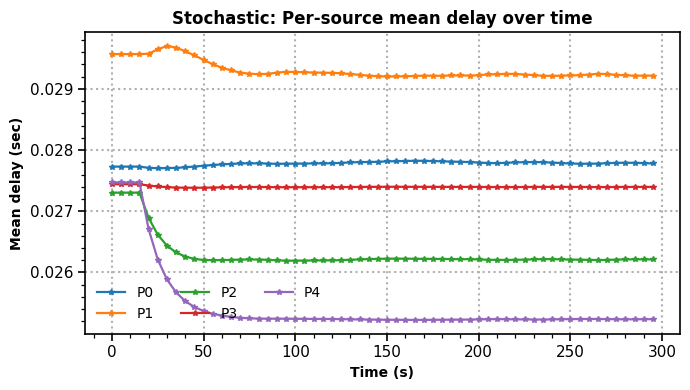

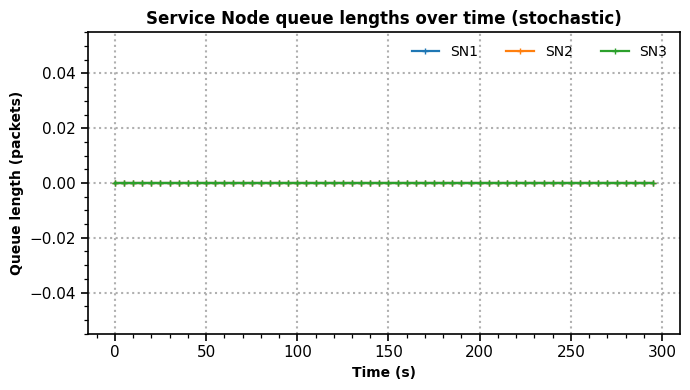

max q_broker per broker: [0. 0. 0.]
mean q_broker per broker: [0. 0. 0.]
fraction nonzero per broker: [0. 0. 0.]

Average split x_ij after warmup:
P0 : {'SN1': 0.48743100989551813, 'SN2': 0.012475206391922955, 'SN3': 0.5000937837125589}
P1 : {'SN1': 0.010217813013684114, 'SN2': 0.4541815058678892, 'SN3': 0.5356006811184265}
P2 : {'SN1': 0.502129683354579, 'SN2': 0.1654635161644446, 'SN3': 0.3324068004809762}
P3 : {'SN1': 0.342217751109803, 'SN2': 0.3286080619584644, 'SN3': 0.32917418693173267}
P4 : {'SN1': 0.3907182330206145, 'SN2': 0.010064400123401802, 'SN3': 0.5992173668559836}

Deterministic dist split x_ij (from dist_flow['L']):
P0 : {'SN1': 0.4829320777077203, 'SN2': 7.837928785718484e-07, 'SN3': 0.5170671384994011}
P1 : {'SN1': 4.0060995206486644e-07, 'SN2': 0.49782610807229233, 'SN3': 0.5021734913177557}
P2 : {'SN1': 0.5047073997711409, 'SN2': 0.16237029902403274, 'SN3': 0.33292230120482647}
P3 : {'SN1': 0.34124260852259913, 'SN2': 0.3291619807498763, 'SN3': 0.3295954107275246}

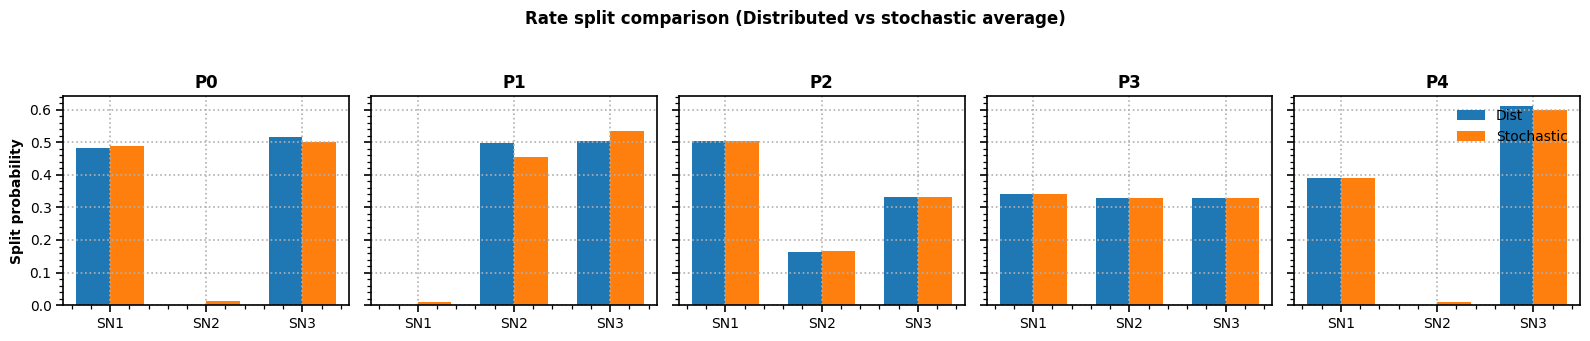

In [20]:
# ============================================================
# Plots: utilities, delays, splits over time  (STYLE CONSISTENT)
# ============================================================


# Reuse this if you already defined it earlier; otherwise keep this definition.
def _stylize_axes(ax, xlabel, ylabel, title):
    ax.set_xlabel(xlabel, fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.grid(True, which="major", linestyle=":", linewidth=1.5)
    ax.minorticks_on()
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    ax.tick_params(axis="both", which="major", width=1.2, length=5, labelsize=11)
    ax.tick_params(axis="both", which="minor", width=0.9, length=3)

def plot_time_series_multi(ax, t, Y, labels, marker="o", markersize=4.5, linewidth=1.6):
    """
    Y: shape (T, k). Plots k lines with a consistent style.
    """
    for k, lab in enumerate(labels):
        ax.plot(
            t, Y[:, k],
            linestyle="-",
            linewidth=linewidth,
            marker=marker,
            markersize=markersize,
            label=str(lab),
        )

# (1) Broker utilization over time
fig, ax = plt.subplots(figsize=(7, 4))
plot_time_series_multi(
    ax, hist_time, hist_util,
    labels=brokers_list,
    marker="o", markersize=3.8, linewidth=1.6
)
_stylize_axes(ax, "Time (s)", r"Utilization  $\hat\Lambda_j/\mu_j$",
             "Service Node utilization over time (EWMA estimate)")
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
plt.show()
plt.close(fig)

# (2) Per-producer mean end-to-end delay over time
fig, ax = plt.subplots(figsize=(7, 4))
plot_time_series_multi(
    ax, hist_time, hist_mean_delay,
    labels=producers_list,
    marker="*", markersize=3.8, linewidth=1.6
)
_stylize_axes(ax, "Time (s)", "Mean delay (sec)",
             "Stochastic: Per-source mean delay over time")
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
plt.show()
plt.close(fig)

# (3) Broker queue lengths over time
fig, ax = plt.subplots(figsize=(7, 4))
plot_time_series_multi(
    ax, hist_time, hist_q_broker,
    labels=brokers_list,
    marker="+", markersize=5.0, linewidth=1.6
)
_stylize_axes(ax, "Time (s)", "Queue length (packets)",
             "Service Node queue lengths over time (stochastic)")
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
plt.show()
plt.close(fig)
print("max q_broker per broker:", hist_q_broker.max(axis=0))
print("mean q_broker per broker:", hist_q_broker.mean(axis=0))
print("fraction nonzero per broker:", (hist_q_broker > 0).mean(axis=0))


# (4) Average split per producer after warmup (deterministic vs stochastic avg)
t0 = WARMUP_WINDOWS
x_avg = hist_x[t0:, :, :].mean(axis=0)   # (m,n)

print("\nAverage split x_ij after warmup:")
for i, p_name in enumerate(producers_list):
    print(p_name, ":", {brokers_list[j]: float(x_avg[i,j]) for j in range(n)})

# Optional: compare against deterministic distributed solution "dist_flow['L']"
try:
    L_det = dist_flow["L"]  # MB/s
    x_det = (L_det / np.maximum(lambdas_total_MB[:, None], 1e-12))

    print("\nDeterministic dist split x_ij (from dist_flow['L']):")
    for i, p_name in enumerate(producers_list):
        print(p_name, ":", {brokers_list[j]: float(x_det[i,j]) for j in range(n)})

    fig, axes = plt.subplots(1, m, figsize=(3.2*m, 3.2), sharey=True)
    if m == 1:
        axes = [axes]
    x_idx = np.arange(n)
    w = 0.35

    for i, ax in enumerate(axes):
        ax.bar(x_idx - w/2, x_det[i,:], width=w, label="Dist")
        ax.bar(x_idx + w/2, x_avg[i,:], width=w, label="Stochastic")
        ax.set_xticks(x_idx)
        ax.set_xticklabels(brokers_list)
        ax.set_title(producers_list[i], fontweight="bold")
        ax.grid(True, which="major", linestyle=":", linewidth=1.2)
        ax.minorticks_on()
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)
        ax.tick_params(axis="both", which="major", width=1.2, length=5, labelsize=10)
        ax.tick_params(axis="both", which="minor", width=0.9, length=3)

    axes[0].set_ylabel("Split probability", fontweight="bold")
    axes[-1].legend(frameon=False, loc="upper right")
    fig.suptitle("Rate split comparison (Distributed vs stochastic average)", y=1.05, fontweight="bold")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

except NameError:
    pass


In [ ]:
# deterministic final utilization (from dist solver)
u_det = dist_flow["L"].sum(axis=0) / MU_brokers_MB   # shape (n,)

# stochastic utilization trace: hist_util is (T, n)
U_post = hist_util[WARMUP_WINDOWS:, :]              # post-warmup only

u_mean = U_post.mean(axis=0)
u_std  = U_post.std(axis=0, ddof=1)                 # sample std

df = pd.DataFrame({
    "u_det": u_det,
    "u_stoch_mean": u_mean,
    "u_stoch_std": u_std,
    "abs_gap": np.abs(u_mean - u_det),
    "rel_gap": np.abs(u_mean - u_det) / np.maximum(u_det, 1e-12),
}, index=brokers_list)

display(df.round(6))


,u_det,u_stoch_mean,u_stoch_std,abs_gap,rel_gap
B0,0.158806,0.155998,0.011092,0.002808,0.017681
B1,0.139029,0.141124,0.005965,0.002095,0.015066
B2,0.102225,0.101635,0.005990,0.000590,0.005770


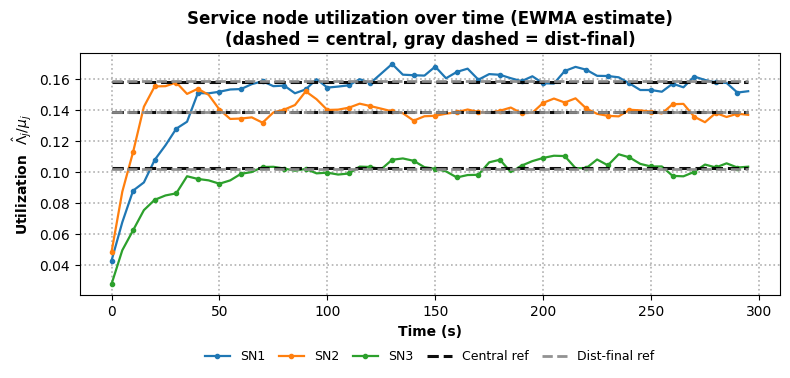

In [21]:
# (1) Broker utilization over time + deterministic references (central + dist)
fig, ax = plt.subplots(figsize=(8,4))

mark_every = max(1, len(hist_time)//25)  # ~25 markers across the plot

# stochastic EWMA utilization trajectories
for j, b in enumerate(brokers_list):
    ax.plot(
        hist_time, hist_util[:, j],
        linewidth=1.6,
        marker="o", markersize=3.0,
        markevery=mark_every,
        label=b
    )

# references
util_dist = dist_flow["L"].sum(axis=0) / np.maximum(MU_brokers_MB, 1e-12)
util_cent = L_flow_central.sum(axis=0) / np.maximum(MU_brokers_MB, 1e-12)

# central ref (black dashed)
for j in range(len(brokers_list)):
    ax.hlines(
        util_cent[j], hist_time[0], hist_time[-1],
        linestyles="--", linewidth=2.2, color="k", alpha=0.95,
        label="Central ref" if j == 0 else None
    )

# dist-final ref (gray dashed)
for j in range(len(brokers_list)):
    ax.hlines(
        util_dist[j], hist_time[0], hist_time[-1],
        linestyles="--", linewidth=2.0, color="0.55", alpha=0.95,
        label="Dist-final ref" if j == 0 else None
    )

# styling
ax.set_xlabel("Time (s)", fontweight="bold")
ax.set_ylabel(r"Utilization  $\hat\Lambda_j/\mu_j$", fontweight="bold")
ax.set_title("Service node utilization over time (EWMA estimate)\n(dashed = central, gray dashed = dist-final)", fontweight="bold")
ax.grid(True, linestyle=":", linewidth=1.2)

# ---- legend: outside + compact ----
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    frameon=False,
    ncol=5,                 # B0 B1 B2 Central Dist
    fontsize=9,
    handlelength=2.0,
    columnspacing=1.1,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18)  # push legend below axes
)

fig.tight_layout()
plt.show()
plt.close(fig)
